# Imports

TODO for tomorrow:
- Refector this Jupyter notebook to support gn_fitting_refactored
- post some prior samples and some reference samples at the same alpha
- check likelihood is actually impacting posterior, should get tighter around datapoints


# Prior and generate perturbations samples 

SyntaxError: invalid syntax (559093670.py, line 1)

In [ ]:
import sqlite3
from contextlib import closing
import pandas as pd
import time
from cosmographi.source.agn import AGNSourceLipunova2018
from cosmographi.utils.perturbations import generate_perturbations_vector
from cosmographi.utils.constants import M_sun
import os
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # pick whichever GPU has more free memory
import caskade as ck
from cosmographi.utils.perturbations import generate_perturbations_vector
import jax.numpy as jnp 
from cosmographi.source.agn import AGNSourceLipunova2018, AGNSourceLipunova2018_no_fourier
from cosmographi.instrument import Instrument
from cosmographi.instrument.rubin import RubinObservatory
import numpy as np
import jax
import matplotlib.pyplot as plt
from cosmographi.utils.constants import M_sun, c_nm
from cosmographi.utils.flux import convert_to_jy, observer_to_rest_time
# jax.config.update("jax_enable_x64", True)
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
import pandas as pd
from cosmographi.utils.perturbations import generate_perturbations_vector
from cosmographi.cosmology import Cosmology
import arviz as az
import blackjax as bx
import jax.scipy.stats as stats
from functools import partial
import cosmographi as cp
import matplotlib.pyplot as plt
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import scipy
#make gif moving alpha from 0 to 4

In [ ]:
import cosmographi.source.agn_fitting_refactored as f
from cosmographi import source_factory
import caskade as ck
import jax
import matplotlib.pyplot as plt

# Generate data

In [ ]:
np.random.seed(0)
key, key2 = jax.random.split(jax.random.PRNGKey(0))

# Extract survey data from the LSST database
# #####################################################################
survey_path = "/home/renee/renee/opsim/baseline_v5.0.1_10yrs.db"
with closing(sqlite3.connect(survey_path)) as conn:
    query = f"""
        SELECT 
            observationId,
            observationStartMJD,
            visitExposureTime,
            numExposures,
            airmass,
            fieldRA, 
            fieldDec, 
            rotTelPos, 
            rotSkyPos, 
            skyBrightness,
            band,
            filter,
            seeingFwhmEff,
            observation_reason
        FROM observations
        LIMIT 50000;
        """
    survey_df = pd.read_sql_query(query, conn)
survey_t = survey_df["observationStartMJD"].values
survey_ra = survey_df["fieldRA"].values
survey_dec = survey_df["fieldDec"].values
survey_exp_time = survey_df["visitExposureTime"].values
survey_airmass = survey_df["airmass"].values
survey_sky_brightness = survey_df["skyBrightness"].values
survey_seeing = survey_df["seeingFwhmEff"].values
survey_PSF_Aeff = 4 * np.pi * (survey_seeing / 2.355) ** 2  # convert FWHM to effective area
survey_band = survey_df["band"].values
survey_obsreason = survey_df["observation_reason"].values


# Create source
#####################################################################

N = 24
perturbations = generate_perturbations_vector (alpha=0.7, n_samples = N)
fourier_perturbations = jnp.fft.rfft(perturbations)
x_r = jnp.real(fourier_perturbations)
x_i = jnp.imag(fourier_perturbations)

print(perturbations)
C = cp.Cosmology()
source_obj = cp.source_factory(AGNSourceLipunova2018, cp.source.effects.MWExtinction_Calzetti00)
S = source_obj(cosmology=C, N=N, A_V_c00mw=0.1, R_V_c00mw=3.1, blackhole_mass=1e10*M_sun, accretion_rate=M_sun, rin_to_rng=6, inclination_angle=0, real_fourier_perturbations=x_r, imag_fourier_perturbations=x_i, start_time=60900, end_time=65000)



#####################################################################
I = cp.RubinObservatory()
I.throughput.trim()
I.throughput.to_dynamic() 
survey_iband, idx_to_bandstr = cp.utils.bandstr_to_bandidx(I.throughput.bands, survey_band, return_dict=True)
nfilter = len(I.throughput.bands)
print(I.get_values().shape)

#TODO: run foward model
#TODO: check recovering
#TODO: folder we dont commit


# Generate mock SN
#####################################################################
Nsn = 1
t_range = (np.min(survey_t), np.max(survey_t))
source_t = np.random.uniform(*t_range, Nsn)
S.t0 = source_t
R = cp.RateConst(cosmology=C, z_min=0.01, z_max=1.0, r=1)
key, subkey = jax.random.split(key)
source_z = R.sample_z(subkey, source_t.shape)
S.z = source_z
print(source_z)
chooseraddec = np.random.choice(
    len(survey_ra), Nsn
)  # fixme, not right distribution, but good enough for testing


source_ra, source_dec = cp.utils.sample_near(
    survey_ra[chooseraddec], survey_dec[chooseraddec], radius_deg=2, n=Nsn
)

print("Matching sources to survey...")
source_matches = cp.utils.cross_match_survey_circle(
    source_tmin = np.full(Nsn, np.min(survey_t)),
    source_tmax= np.full(Nsn, np.max(survey_t)),
    source_ra=source_ra,
    source_dec=source_dec,
    survey_t=survey_t,
    survey_ra=survey_ra,
    survey_dec=survey_dec,
    survey_fov=3.5,  # degrees, LSST field of view
)
print(f"Matched {len(source_matches)} sources to survey observations.")
for i in list(source_matches.keys()):
    if len(source_matches[i]) < 5:
        del source_matches[
            i
        ]  # drop sources with fewer than 5 matches, not enough data for lightcurve
        continue
print(f"Matched {len(source_matches)} sources worth examining.")
# print(source_matches)
# TODO: MAKE PRIORS
# P = cp.source.prior.SALT2_SK16Prior()
# x1, c = P.prior_sample(source_t.shape[0])
# S.x1 = x1
# S.c = c
sel_src = np.sort(list(source_matches.keys()))
print(sel_src)

# Build params input
#####################################################################
source_values = np.array(S.get_values())
survey_values = np.array(I.get_values())
keys = []
bands = []
exp_times = []
sky_brightnesses = []
PSF_Aeffs = []
obs_t = []
obs_reasons = []
source_params = []
survey_params = []
for i in sel_src:
    _subkeys = jax.random.split(key, len(source_matches[i]) + 1)
    key, subkeys = _subkeys[0], _subkeys[1:]
    keys.append(subkeys)
    bands.append(survey_iband[source_matches[i]])
    exp_times.append(survey_exp_time[source_matches[i]])
    sky_brightnesses.append(survey_sky_brightness[source_matches[i]])
    PSF_Aeffs.append(survey_PSF_Aeff[source_matches[i]])
    obs_t.append(survey_t[source_matches[i]])
    obs_reasons.append(survey_obsreason[source_matches[i]])
    source_params.append(jnp.repeat(source_values[i][None, :], len(source_matches[i]), axis=0))
    survey_params.append(survey_airmass[source_matches[i]][:, None])  # shape (n_obs, 1)
keys = jnp.array(np.concatenate(keys))
bands = jnp.array(np.concatenate(bands))
exp_times = jnp.array(np.concatenate(exp_times))
sky_brightnesses = jnp.array(np.concatenate(sky_brightnesses))
PSF_Aeffs = jnp.array(np.concatenate(PSF_Aeffs))
obs_t = jnp.array(np.concatenate(obs_t))
obs_reasons = np.array(np.concatenate(obs_reasons))
source_params = jnp.array(np.concatenate(source_params, axis=0))
survey_params = jnp.array(np.concatenate(survey_params, axis=0))


# Run mock survey lightcurves
#####################################################################
vobs = jax.jit(jax.vmap(I.observe, in_axes=(0, 0, 0, 0, 0, None, 0, 0, 0)), static_argnums=(5,))
start = time.time()
LCs = []
nobs = len(keys)

#TODO: had to lower, what is eating up my memory??

batch_size = 50

print("batch_size =", batch_size)
i = 0
print("keys", keys[i:i+batch_size].shape)
print("bands", bands[i:i+batch_size].shape)
print("exp_times", exp_times[i:i+batch_size].shape)
print("sky_brightnesses", sky_brightnesses[i:i+batch_size].shape)
print("PSF_Aeffs", PSF_Aeffs[i:i+batch_size].shape)
print("obs_t", obs_t[i:i+batch_size].shape)
print("source_params", source_params[i:i+batch_size].shape)
print("survey_params", survey_params[i:i+batch_size].shape)

for i in range(0, nobs, batch_size):
    LCs.append(
        vobs(
            keys[i : i + batch_size],
            bands[i : i + batch_size],
            exp_times[i : i + batch_size],
            sky_brightnesses[i : i + batch_size],
            PSF_Aeffs[i : i + batch_size],
            S,
            obs_t[i : i + batch_size],
            source_params[i : i + batch_size],  
            survey_params[i : i + batch_size],
        )
    )
LCs = tuple(
    jnp.concatenate(tuple(LCs[i][f] for i in range(len(LCs))), axis=0) for f in range(len(LCs[0]))
)

seli = sel_src[0]
spot = sum(len(source_matches[i]) for i in sel_src if i < seli)
times = obs_t[spot : spot + len(source_matches[seli])]
lc_obs = LCs[0][spot : spot + len(source_matches[seli])]
lc_err = LCs[1][spot : spot + len(source_matches[seli])]

print(lc_obs)



[ 0.33950398  2.59116864  2.18297007  2.22925089 -4.3699177  -0.51678521
  0.28022903 -1.14981753 -2.61184155 -0.57962685 -1.72727223 -0.29024299
  0.93236387 -0.90907699  2.4211857   1.93231646 -1.2146463  -2.08356479
 -0.30276377 -1.55615088  3.69395721 -1.45177483  0.75023747  1.41029831]
(1,)
[0.83781118]
Matching sources to survey...
Matched 1 sources to survey observations.
Matched 1 sources worth examining.
[0]
batch_size = 50
keys (8, 2)
bands (8,)
exp_times (8,)
sky_brightnesses (8,)
PSF_Aeffs (8,)
obs_t (8,)
source_params (8, 2)
survey_params (8, 1)


TypeError: irfft() got an unexpected keyword argument 'shape'

In [ ]:
times = S.times
print(jnp.shape(times))
print(jnp.shape(S.perturbations.value))

(24,)
(24,)


In [ ]:
kwargs = {"obs_t": obs_t, "band": bands, "exp_time": exp_times, "sky_brightness": sky_brightnesses, "PSF_Aeff": PSF_Aeffs, "times": times, "z": source_z, 
        "source": S,
        "alpha": 0.7,
        "A": S.perturbations.shape[0],
}



In [ ]:
print( S.perturbations.shape[0])

24


(z, alpha, A, real_fourier_perturbations, imag_fourier_perturbations)
{'blackhole_mass': Array(1.98847e+40, dtype=float64), 'accretion_rate': Array(1.98847e+30, dtype=float64), 'inclination_angle': Array(0, dtype=int64, weak_type=True), 'rin_to_rng': Array(6, dtype=int64, weak_type=True), 'alpha': 0.7, 'A': 24, 'imag_fourier_perturbations': Array([ 0.        ,  4.62535867, -7.19579232, -1.93120939, -4.49462837,
       -2.38499178, -1.16497915, -2.23380294, -8.69126208,  7.41904385,
        3.70324326,  1.54040521,  0.        ], dtype=float64), 'real_fourier_perturbations': Array([-2.10942375e-15, -1.94529347e+00, -8.13894251e-01,  1.08380669e+01,
        7.08830017e+00, -7.35024858e-02,  2.23397108e+00, -3.07433820e+00,
       -1.71511963e+00,  6.27736287e+00,  5.99003090e+00, -1.23099975e+00,
       -1.58000295e+00], dtype=float64)}


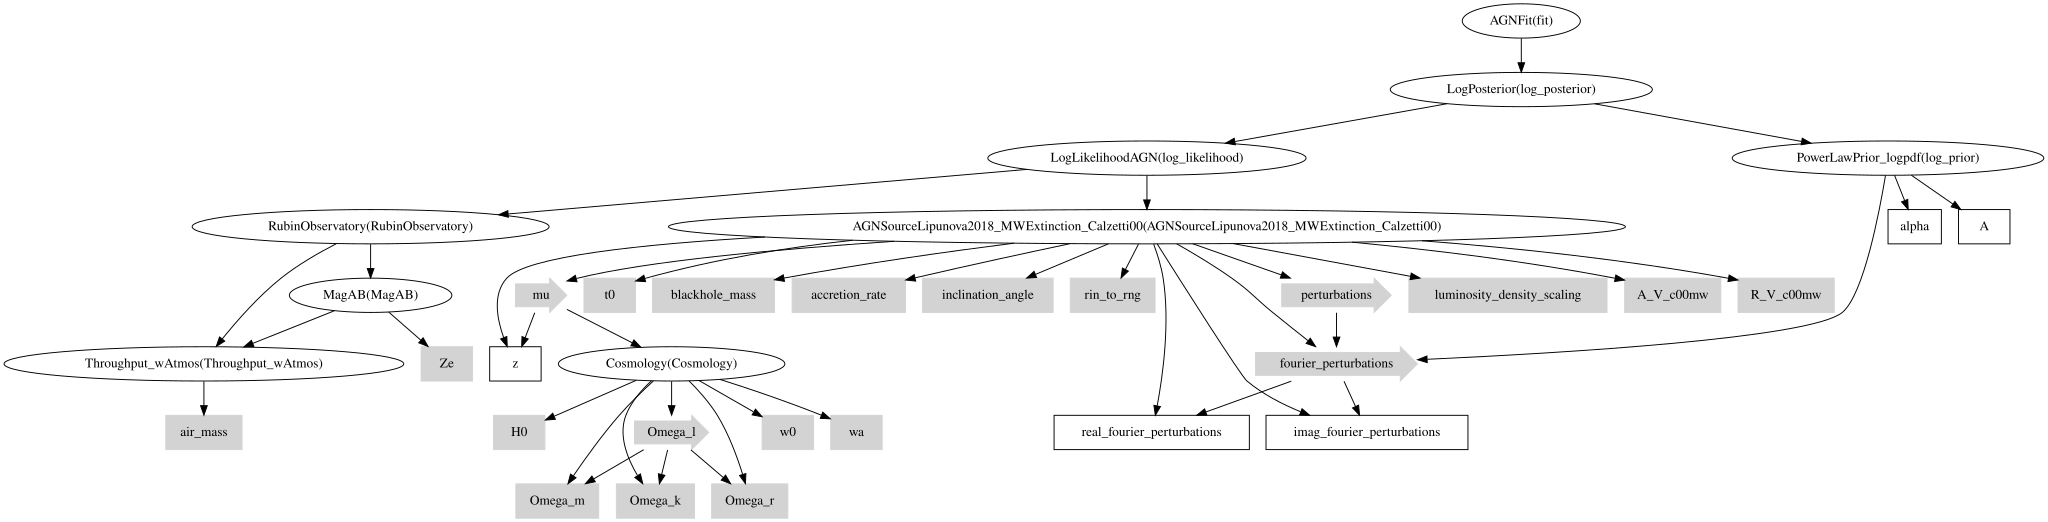

1
caling warmup.run


ValueError: xp and fp must be one-dimensional arrays of equal size

In [ ]:
keys = jax.random.split(jax.random.key(42))
fitter = f.AGNFit(name="fit", key=keys[0], instrument=I, y=lc_obs, y_err=lc_err, **kwargs)
fitter.log_posterior.log_likelihood.source.t0.to_static()
fitter.log_posterior.log_likelihood.source.luminosity_density_scaling.to_static()
fitter.log_posterior.log_likelihood.instrument.throughput.air_mass.to_static()
fitter.log_posterior.log_likelihood.source.real_fourier_perturbations.to_dynamic()
fitter.log_posterior.log_likelihood.source.imag_fourier_perturbations.to_dynamic()
fitter.log_posterior.log_prior.alpha.to_dynamic()
fitter.log_posterior.log_prior.A.to_dynamic()
print(fitter.dynamic_params)
true_values = {"blackhole_mass": S.blackhole_mass.value, "accretion_rate": S.accretion_rate.value, "inclination_angle": S.inclination_angle.value, "rin_to_rng": S.rin_to_rng.value, "alpha": 0.7, "A":  S.perturbations.shape[0], "imag_fourier_perturbations":S.imag_fourier_perturbations.value, "real_fourier_perturbations": S.real_fourier_perturbations.value}
print(true_values)
display(fitter.graphviz())
key = jax.random.key(42)
# print(fitter.log_posterior.log_likelihood(fitter.log_posterior.log_likelihood.get_values(), key=key))
d2 = fitter.plot(true_values=true_values)

In [ ]:
real_f = jnp.asarray(jnp.reshape(d2["real_fourier_perturbations"], (d2["real_fourier_perturbations"].shape[0] * d2["real_fourier_perturbations"].shape[1], d2["real_fourier_perturbations"].shape[2])))
imag_f = jnp.asarray(jnp.reshape(d2["imag_fourier_perturbations"], (d2["imag_fourier_perturbations"].shape[0] * d2["imag_fourier_perturbations"].shape[1], d2["imag_fourier_perturbations"].shape[2])))
fourier_posterior = real_f + 1j * imag_f
perturbations_posterior = jnp.fft.irfft(fourier_posterior, n=S.perturbations.shape[0])
q5_perturbations = jnp.percentile(perturbations_posterior, 5, axis=0)
q95_perturbations = jnp.percentile(perturbations_posterior, 95, axis=0)
t = jnp.linspace(start=S.start_time.value, stop=S.end_time.value, num=len(S.perturbations.value))
plt.fill_between(t, q5_perturbations, q95_perturbations, color="blue", alpha=0.25, label="90% Credible Interval for posterior perturbations")
plt.plot(t, S.perturbations.value, color="red", label="True Perturbations")
for obs in obs_t:
    plt.axvline(obs, color="black", label="Observation Times")
plt.xlabel("Time (MJD)")
plt.ylabel("Perturbations")
plt.legend(fontsize="x-small")
plt.show()

In [ ]:

#TODO: check key management

# kwargs = {"band": bands, "exp_time": exp_times, "sky_brightness": sky_brightnesses, "PSF_Aeff": PSF_Aeffs, "times": times, "z": source_z}
# fitter = f.AGNFit(name="fit", key=keys[0], instrument=I, y=lc_obs, y_err=lc_err, **kwargs)

# print(fitter.log_posterior.log_likelihood.source.luminosity_density_scaling.value)

# # fitter.log_posterior.log_likelihood.source.blackhole_mass.to_dynamic()
# # fitter.log_posterior.log_likelihood.source.accretion_rate.to_dynamic()
# # fitter.log_posterior.log_likelihood.source.rin_to_rng.to_dynamic()
# # fitter.log_posterior.log_likelihood.source.inclination_angle.to_dynamic()
# # fitter.log_posterior.log_likelihood.source.A_V_c00mw.to_dynamic()
# # fitter.log_posterior.log_likelihood.source.R_V_c00mw.to_dynamic()
# fitter.log_posterior.log_likelihood.source.luminosity_density_scaling.to_static()
# fitter.log_posterior.log_likelihood.source.t0.to_static()
# fitter.log_posterior.log_likelihood.instrument.throughput.air_mass.to_static()
# fitter.log_posterior.log_prior.alpha.to_dynamic()
# fitter.log_posterior.log_prior.A.to_dynamic()

# print(fitter.dynamic_params)

In [ ]:
# true_values = {"blackhole_mass": S.blackhole_mass.value, "accretion_rate": S.accretion_rate.value, "inclination_angle": S.inclination_angle.value, "rin_to_rng": S.rin_to_rng.value, "alpha": 0.7, "A": 1, "perturbations":S.perturbations.value}
# print(true_values)

# print(fitter.log_posterior(fitter.log_posterior.get_values()))
# key = jax.random.key(42)
# print(fitter.log_posterior.log_likelihood(fitter.log_posterior.log_likelihood.get_values(), key=key))
# print(fitter.log_posterior.log_prior(fitter.log_posterior.log_prior.get_values()))
# d = fitter.plot(true_values=true_values)

#TODO: sample from the prior

# verify acceptance rate is acc correct


In [ ]:
# fitter = f.AGNFitPrior(name="fit", key=keys[0], instrument=I, y=lc_obs, y_err=lc_err, **kwargs)

# print('hi')
# print(fitter.log_posterior.log_likelihood.source.luminosity_density_scaling.value)

# fitter.graphviz()

# # fitter.log_posterior.log_likelihood.source.blackhole_mass.to_dynamic()
# # fitter.log_posterior.log_likelihood.source.accretion_rate.to_dynamic()
# # fitter.log_posterior.log_likelihood.source.rin_to_rng.to_dynamic()
# # fitter.log_posterior.log_likelihood.source.inclination_angle.to_dynamic()
# # fitter.log_posterior.log_likelihood.source.A_V_c00mw.to_dynamic()
# # fitter.log_posterior.log_likelihood.source.R_V_c00mw.to_dynamic()
# # fitter.log_posterior.log_likelihood.source.perturbations.to_dynamic()
# fitter.log_posterior.log_likelihood.source.t0.to_static()
# fitter.log_posterior.log_likelihood.source.luminosity_density_scaling.to_static()
# fitter.log_posterior.log_likelihood.instrument.throughput.air_mass.to_static()
# fitter.log_posterior.log_prior.real_fourier_perturbations.to_dynamic()
# fitter.log_posterior.log_prior.imag_fourier_perturbations.to_dynamic()
# fitter.log_posterior.log_prior.alpha.to_dynamic()
# fitter.log_posterior.log_prior.A.to_dynamic()


# print(fitter.dynamic_params)
# true_values = {"blackhole_mass": S.blackhole_mass.value, "accretion_rate": S.accretion_rate.value, "inclination_angle": S.inclination_angle.value, "rin_to_rng": S.rin_to_rng.value, "alpha": 0.7, "A":  S.perturbations.shape[0], "imag_fourier_perturbations":S.imag_fourier_perturbations.value, "real_fourier_perturbations": S.real_fourier_perturbations.value}
# print(true_values)



# key = jax.random.key(42)
# print(fitter.log_posterior.log_likelihood(fitter.log_posterior.log_likelihood.get_values(), key=key))

# d = fitter.plot(true_values=true_values)

hi
1
(alpha, A, real_fourier_perturbations, imag_fourier_perturbations)
{'blackhole_mass': Array(1.98847e+40, dtype=float64), 'accretion_rate': Array(1.98847e+30, dtype=float64), 'inclination_angle': Array(0, dtype=int64, weak_type=True), 'rin_to_rng': Array(6, dtype=int64, weak_type=True), 'alpha': 0.7, 'A': 24, 'imag_fourier_perturbations': Array([  0.        ,   5.51072365,  -1.82535855,  -3.56576955,
        -1.82441553,   3.56623974, -10.35597266,   6.04075807,
       -13.54785198,  -1.09996591,  -2.49786701,  -2.46030245,
         0.        ], dtype=float64), 'real_fourier_perturbations': Array([-8.88178420e-16,  1.11237002e+01,  1.13047660e+01,  3.69159728e+00,
       -4.26474173e+00,  3.54185439e+00, -3.52780384e+00,  4.20269641e+00,
        2.48807024e+00, -5.37419997e+00, -4.63446762e+00,  4.16866934e+00,
        9.01072407e+00], dtype=float64)}
-38642.686323012545
1
caling warmup.run
HMCState(position=Traced<float64[28]>with<DynamicJaxprTrace>, logdensity=Traced<float64[]>wi

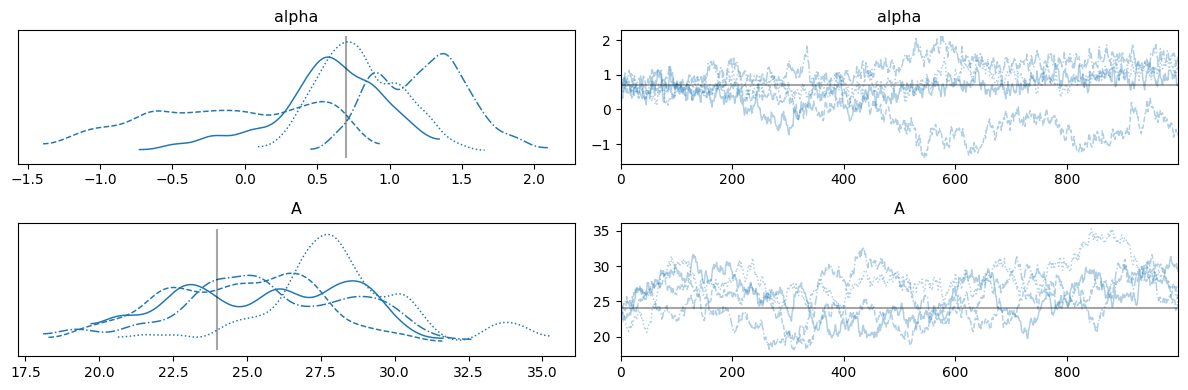

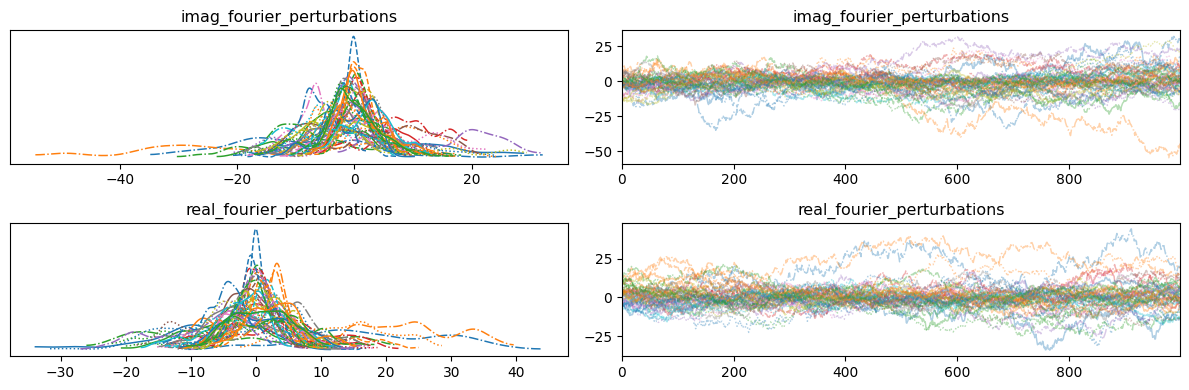

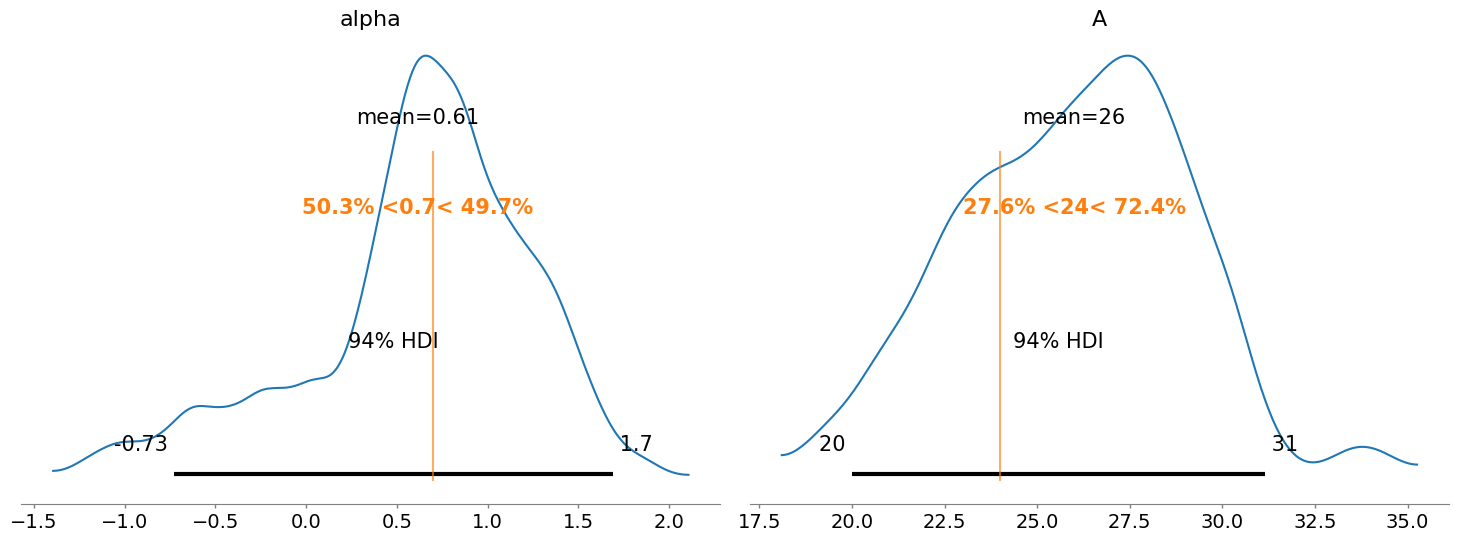

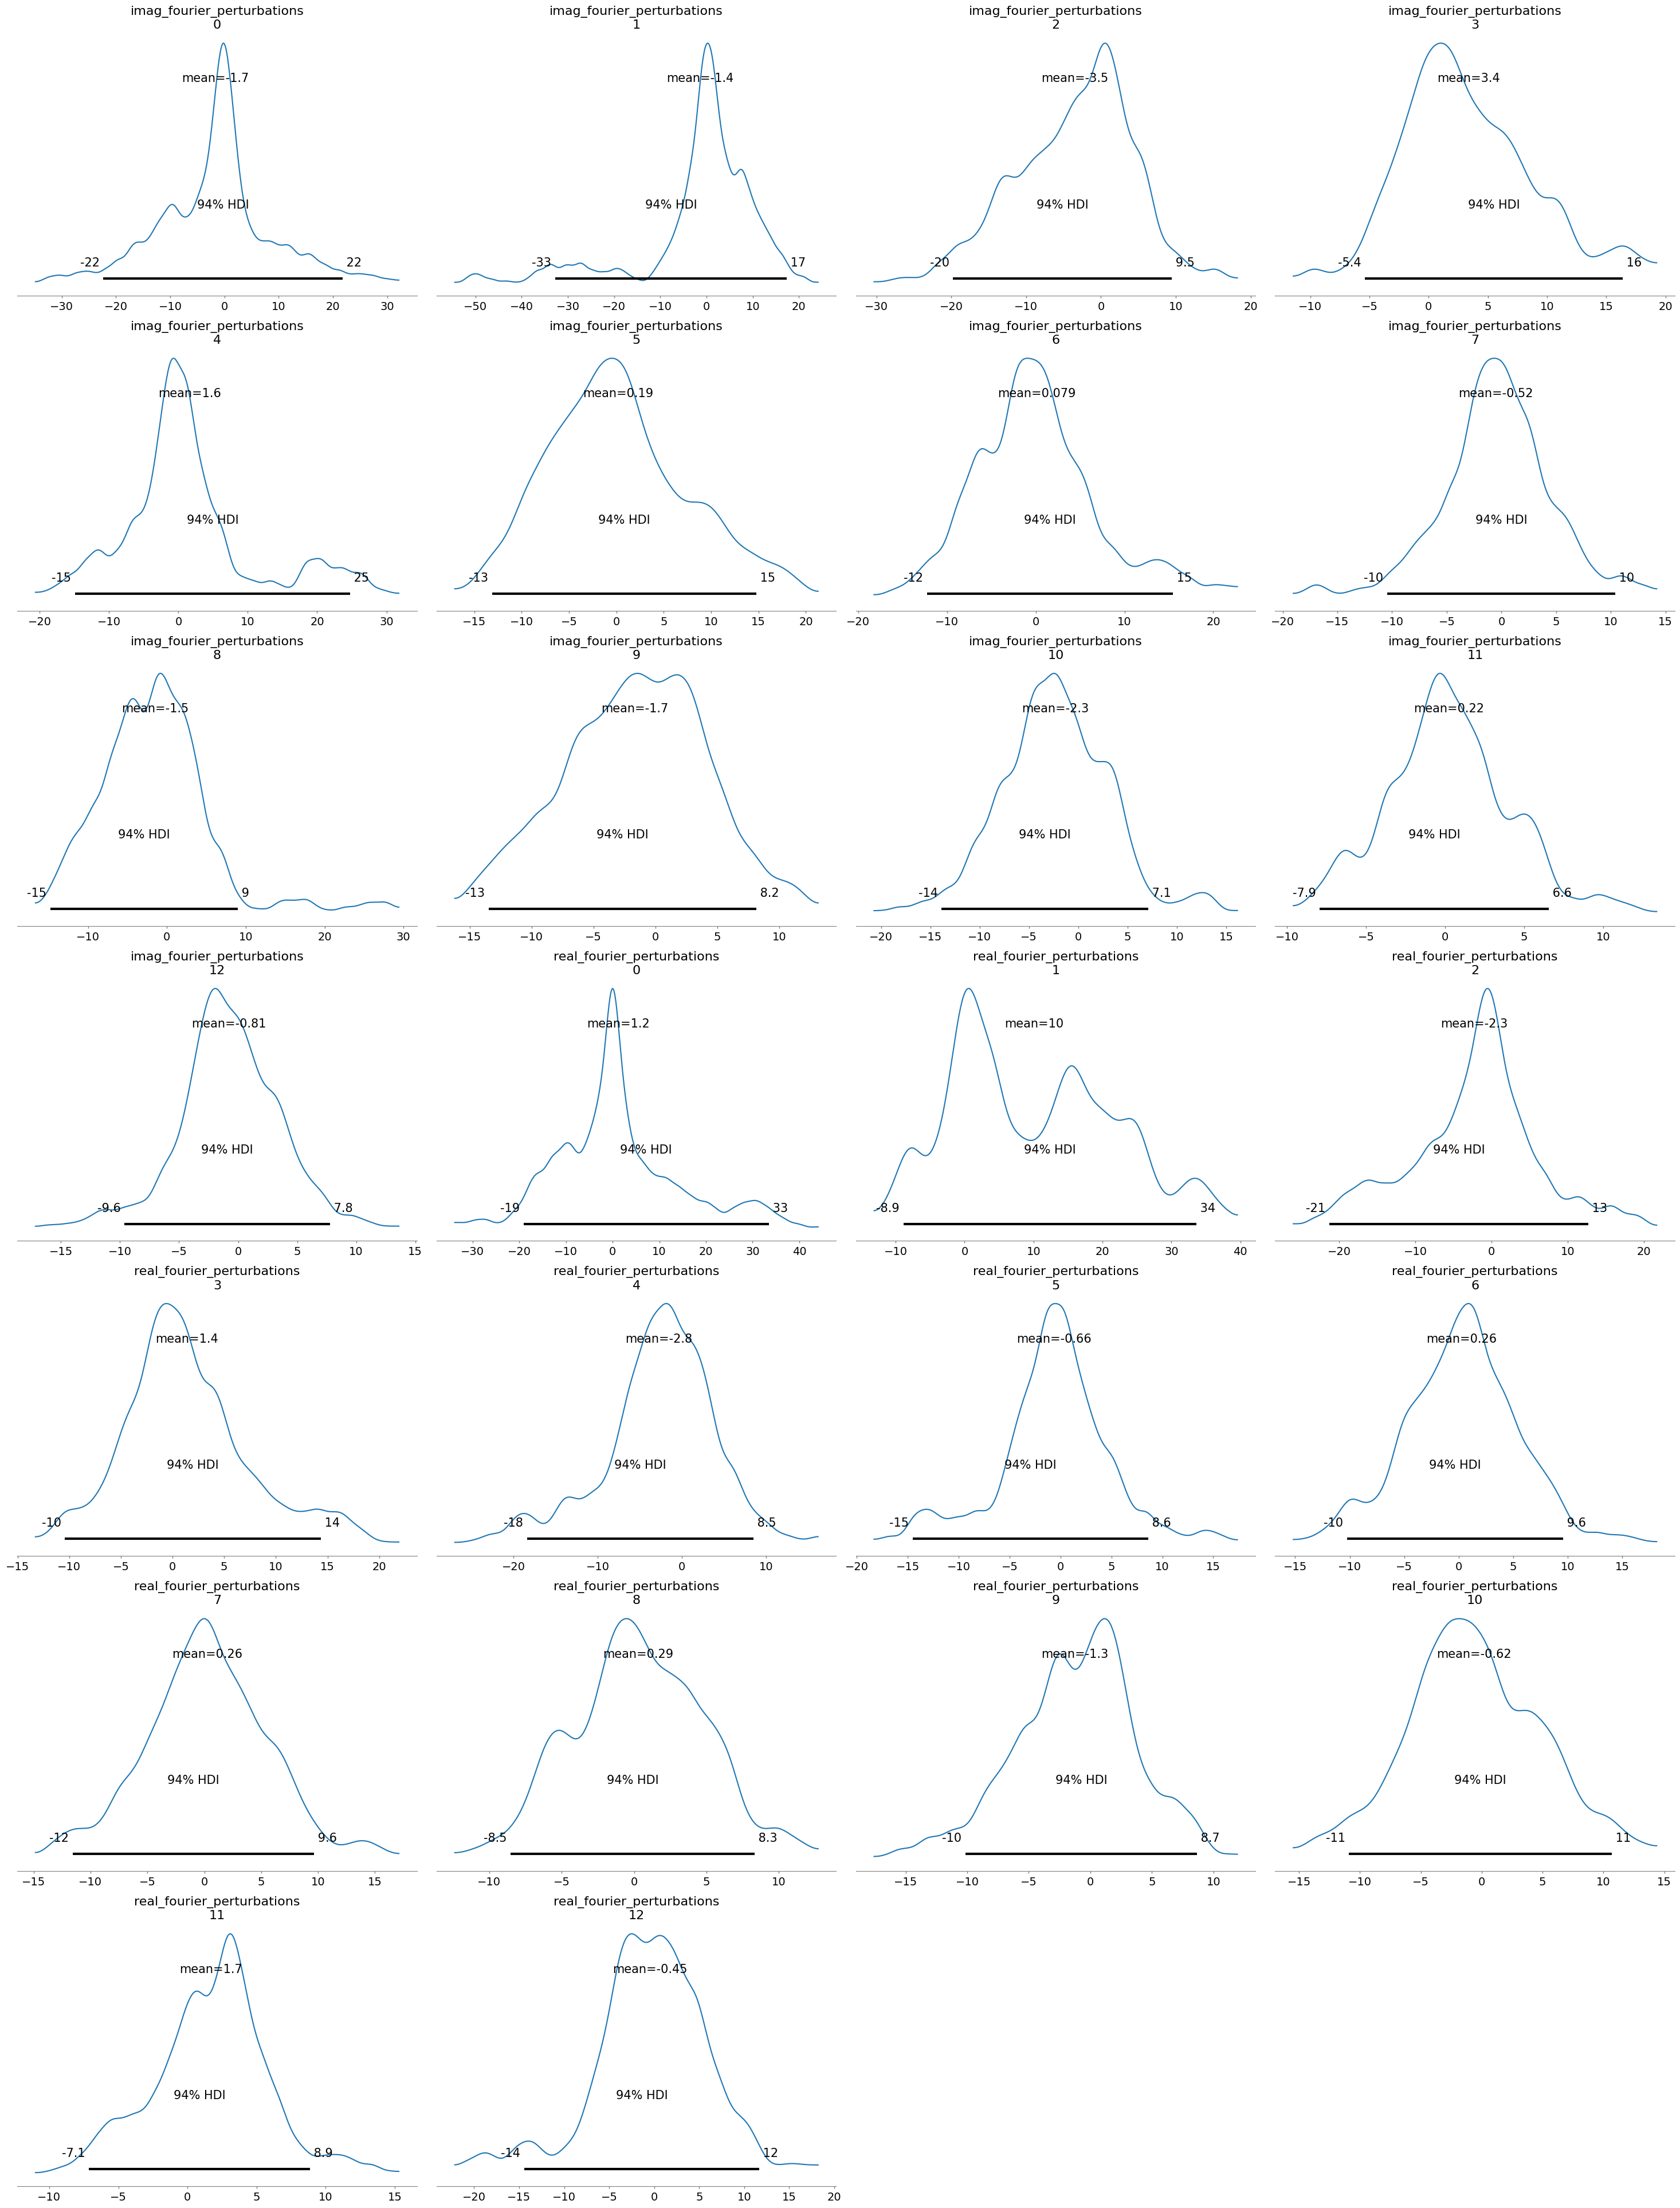

/home/zoe/cosmographi/.venv/lib/python3.12/site-packages/arviz/plots/backends/matplotlib/pairplot.py:233: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


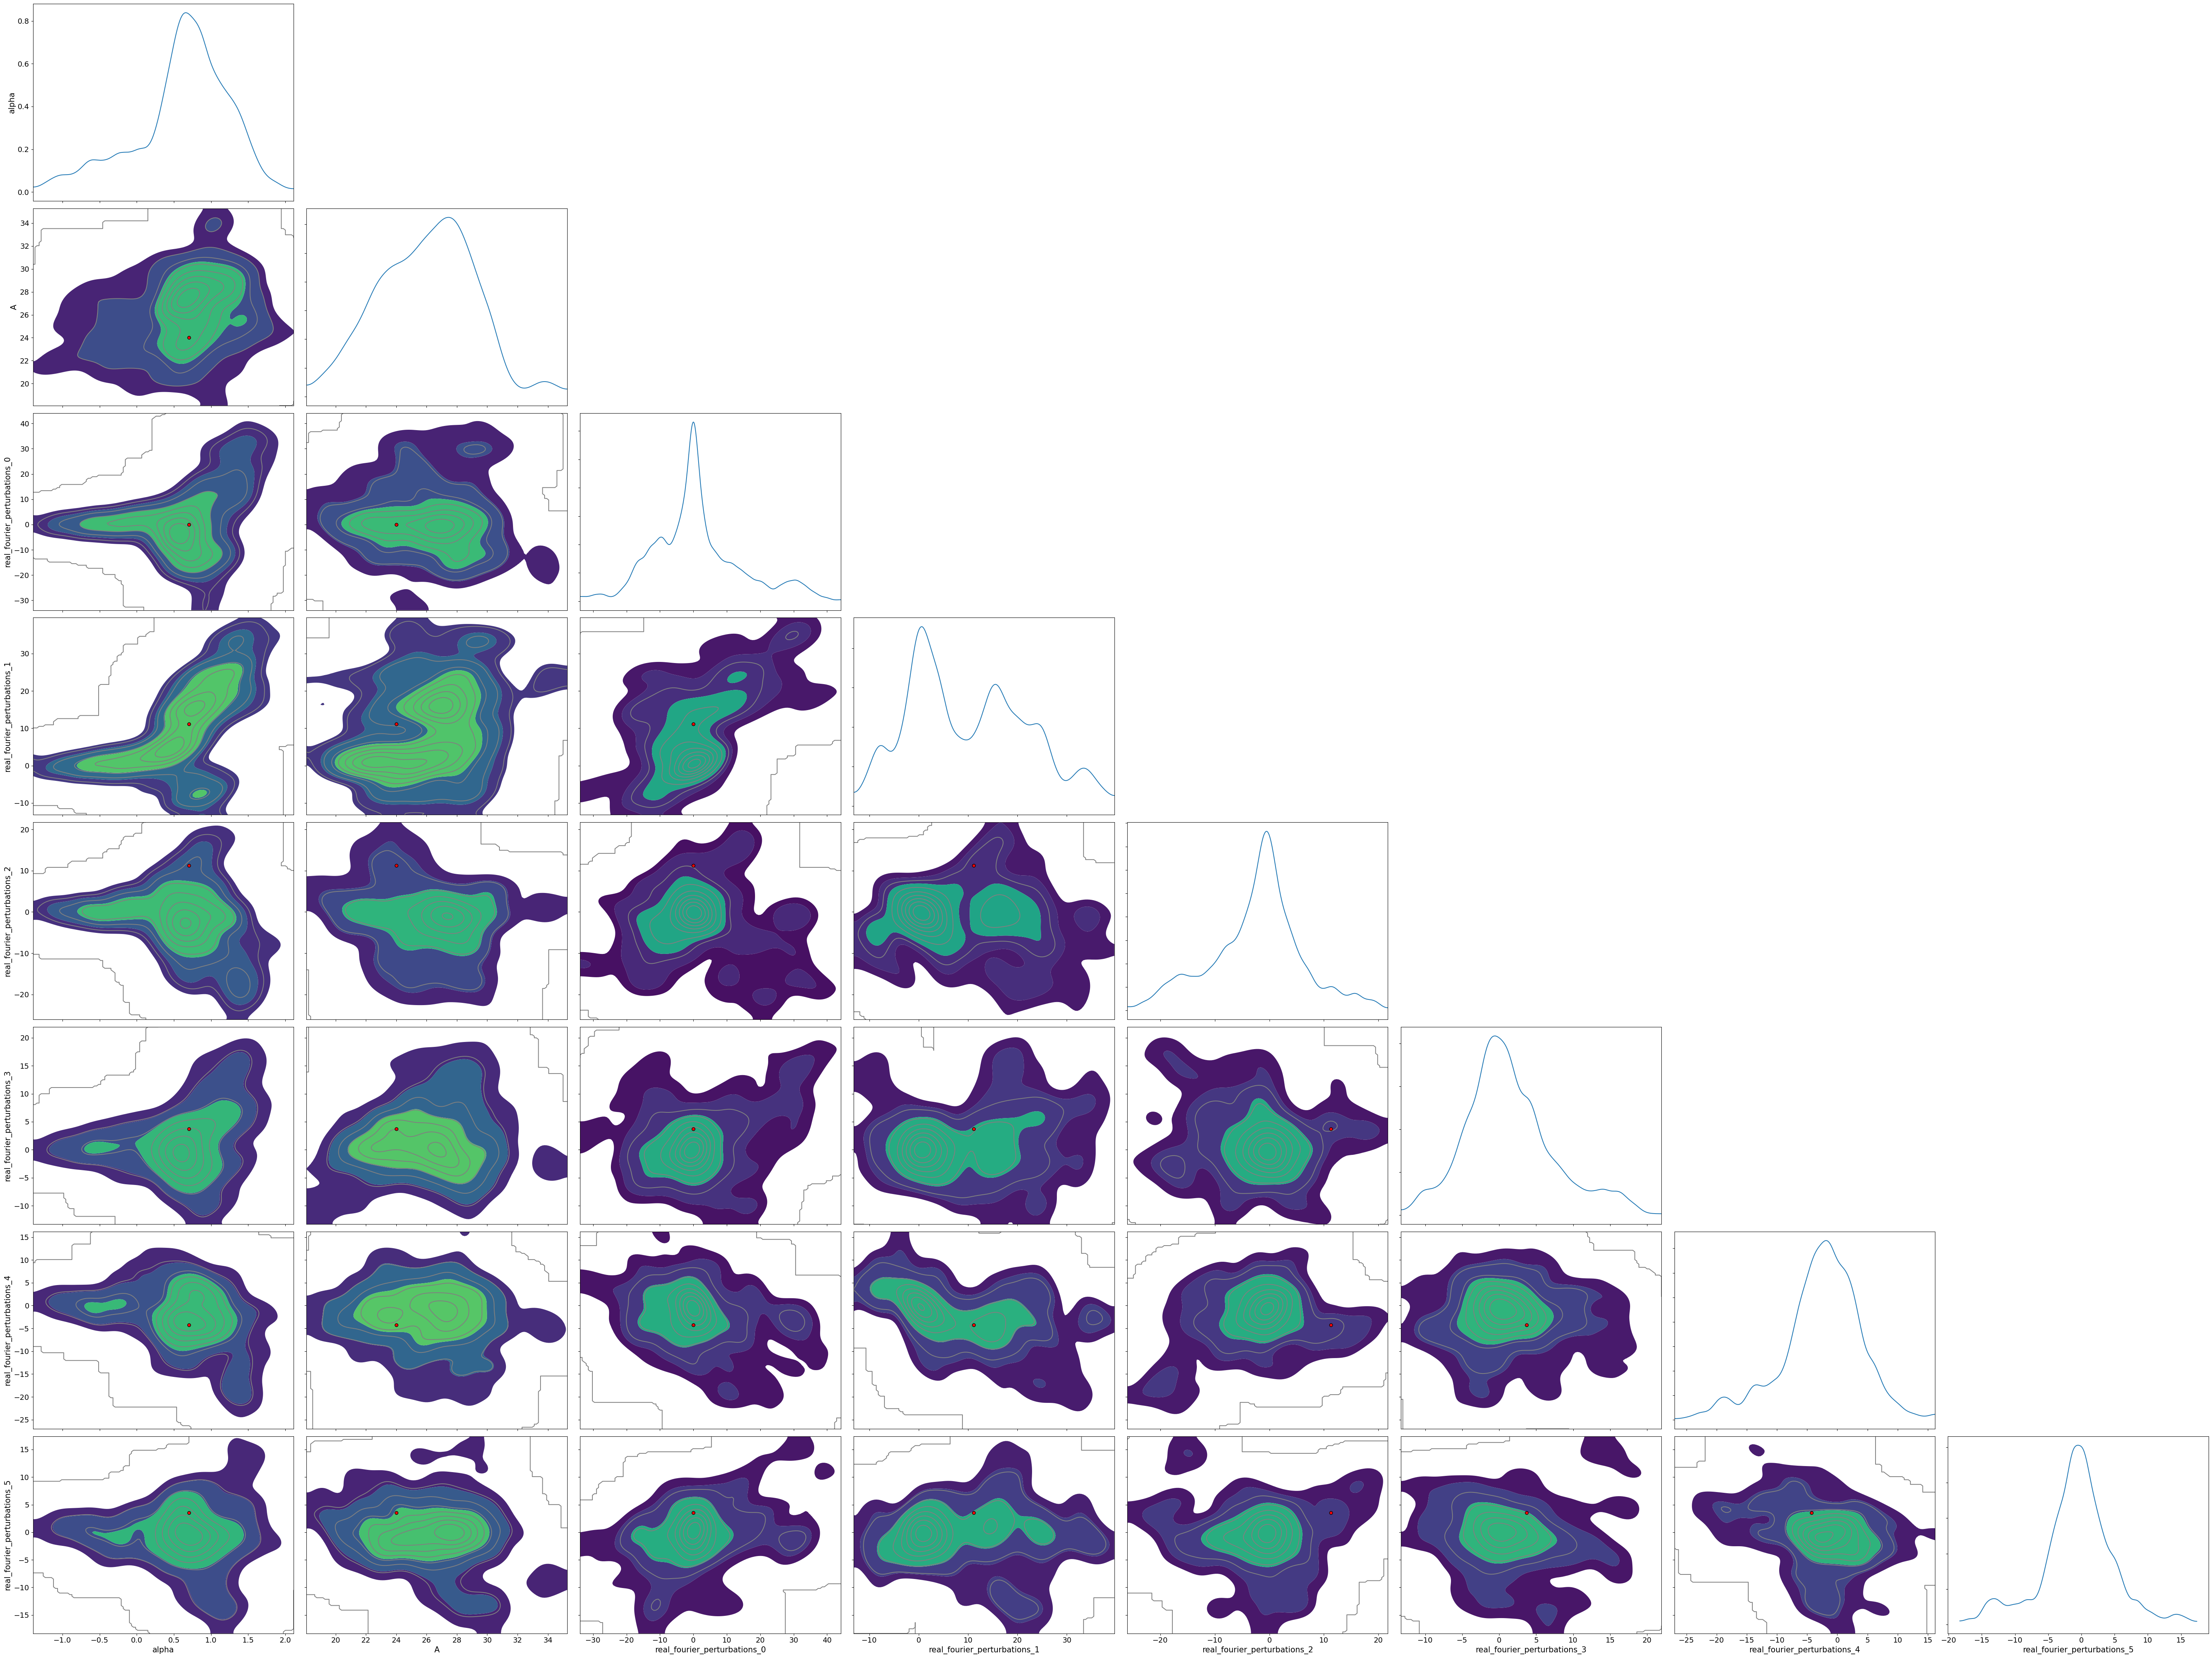

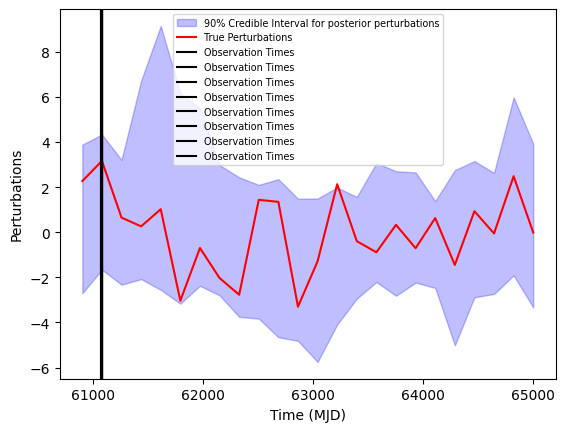

In [ ]:
print(len(S.real_fourier_perturbations.value))

13


In [ ]:
t = jnp.linspace(0, len(S.real_fourier_perturbations.value), len(S.real_fourier_perturbations.value))
real_lower = bounds["real_fourier_perturbations"].sel(hdi="lower").values
real_upper = bounds["real_fourier_perturbations"].sel(hdi="higher").values
imag_lower = bounds["imag_fourier_perturbations"].sel(hdi="lower").values
imag_upper = bounds["imag_fourier_perturbations"].sel(hdi="higher").values
plt.plot(t, S.real_fourier_perturbations.value, color='blue', label='True Real Fourier Coefficient')
plt.fill_between(t, real_lower, real_upper, color='blue', alpha=0.3, label='95% HDI for Real Fourier Coefficient')
plt.plot(t, S.imag_fourier_perturbations.value, color='red', label='True Imaginary Fourier Coefficient')
plt.fill_between(t, imag_lower, imag_upper, color='red', alpha=0.3, label='95% HDI for Imaginary Fourier Coefficient')
plt.legend(fontsize="x-small")
plt.xlabel("Fourier coefficient index")
plt.ylabel("Fourier coefficient value")
plt.show()

NameError: name 'bounds' is not defined

In [ ]:
print(S.perturbations.shape[0])

4


In [ ]:
print(obs_t)


true_perts = []
for time in obs_t:
    time_rest = cp.utils.flux.observer_to_rest_time(time, z=S.z.value)
    true_perts.append(S.perturbations.value[jnp.searchsorted(times, time_rest)])


[61066.22895891 61066.25034739 61079.14235439 61079.16580924
 61080.15123313 61080.15165097 61081.18165556 61081.2057113 ]
